# Obesity Level Classification

Самостоятельный ML-проект по многоклассовой классификации уровней массы тела: EDA, подготовка данных, сравнение моделей, подбор гиперпараметров, отбор признаков и проверка статистических гипотез.

**Датасет:** *Estimation of Obesity Levels Based On Eating Habits and Physical Condition*  
**Источник:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition)  
**Дополнительная страница:** [Kaggle](https://www.kaggle.com/datasets/fatemehmehrparvar/obesity-levels)

Датасет содержит более 2 000 записей, сочетает числовые и категориальные признаки и позволяет исследовать качество моделей, дисбаланс классов, переобучение и важность факторов.


## Гипотезы (сформулированы до анализа)

1. **H1.** Антропометрические признаки (`BMI`, `Weight`, `Height`) окажутся главными по важности у случайного леса; как минимум два из них войдут в топ-3.
2. **H2.** Логистическая регрессия превзойдёт одиночное дерево решений по test macro-F1, потому что классы в значительной степени разделяются упорядоченными антропометрическими границами.
3. **H3.** У лучшей модели accuracy и macro-F1 будут отличаться менее чем на 0.02, поскольку классы близки по размеру.
4. **H4.** Неограниченное дерево будет переобучаться сильнее дерева глубины 5: разрыв `train accuracy - test accuracy` будет больше.
5. **H5.** Отбор 10 лучших преобразованных признаков методом `SelectKBest` уменьшит test macro-F1 логистической регрессии не более чем на 0.02.
6. **H6.** Доля классов ожирения среди людей с семейной историей избыточного веса будет минимум на 0.10 выше, чем среди людей без неё.
7. **H7.** Физическая активность (`FAF`) отрицательно связана с порядковым уровнем массы тела: Spearman ρ < -0.15 и p-value < 0.05.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from scipy.stats import chi2_contingency, spearmanr

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_validate, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

## 1. Загрузка и первичная проверка данных

In [2]:
DATA_PATH = Path("data/ObesityDataSet_raw_and_data_sinthetic.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Не найден файл {DATA_PATH}. Запустите ноутбук из папки проекта."
    )

raw = pd.read_csv(DATA_PATH)
print(f"Размер исходных данных: {raw.shape[0]} строк × {raw.shape[1]} столбцов")
display(raw.head())

Размер исходных данных: 2111 строк × 17 столбцов


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
quality = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "n_unique": raw.nunique()
})
display(quality)
print("Полных дубликатов:", raw.duplicated().sum())

,dtype,missing,n_unique
Gender,str,0,2
Age,float64,0,1402
Height,float64,0,1574
Weight,float64,0,1525
family_history_with_overweight,str,0,2
FAVC,str,0,2
FCVC,float64,0,810
NCP,float64,0,635
CAEC,str,0,4
SMOKE,str,0,2


Полных дубликатов: 24


Пропусков нет. Полные дубликаты удаляются **до** train/test split, чтобы одна и та же запись не могла попасть одновременно в обучение и тест. Для числовых и категориальных признаков всё равно используются imputers: это делает pipeline устойчивым к будущим данным с пропусками.

In [4]:
df = raw.drop_duplicates().reset_index(drop=True).copy()
df["BMI"] = df["Weight"] / df["Height"] ** 2

target = "NObeyesdad"
print(f"После удаления дубликатов: {len(df)} строк")
display(df.describe(include="all").T)

После удаления дубликатов: 2087 строк


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2087,2,Male,1052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2087.0,NaN,NaN,NaN,24.35309,6.368801,14.0,19.915937,22.847618,26.0,61.0
Height,2087.0,NaN,NaN,NaN,1.702674,0.093186,1.45,1.630178,1.701584,1.769491,1.98
Weight,2087.0,NaN,NaN,NaN,86.85873,26.190847,39.0,66.0,83.1011,108.015907,173.0
family_history_with_overweight,2087,2,yes,1722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FAVC,2087,2,yes,1844,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FCVC,2087.0,NaN,NaN,NaN,2.421466,0.534737,1.0,2.0,2.396265,3.0,3.0
NCP,2087.0,NaN,NaN,NaN,2.701179,0.764614,1.0,2.697467,3.0,3.0,4.0
CAEC,2087,4,Sometimes,1761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SMOKE,2087,2,no,2043,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. EDA: распределения, дисбаланс классов и связи

,count,share
NObeyesdad,,
Insufficient_Weight,267,0.127935
Overweight_Level_I,276,0.132247
Normal_Weight,282,0.135122
Overweight_Level_II,290,0.138955
Obesity_Type_II,297,0.142310
Obesity_Type_III,324,0.155247
Obesity_Type_I,351,0.168184


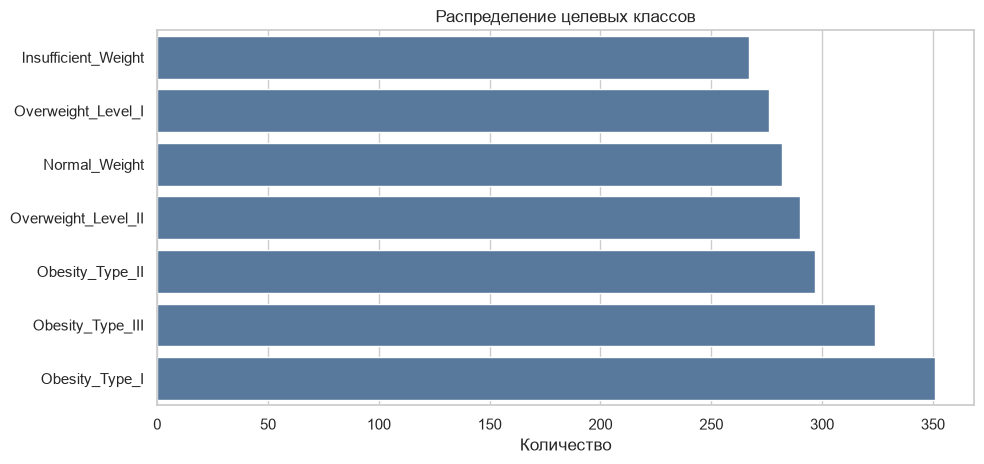

Отношение размера крупнейшего класса к наименьшему: 1.31


In [5]:
class_counts = df[target].value_counts().sort_values()
class_share = (class_counts / len(df)).rename("share")
display(pd.concat([class_counts.rename("count"), class_share], axis=1))

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax, color="#4C78A8")
ax.set(title="Распределение целевых классов", xlabel="Количество", ylabel="")
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Отношение размера крупнейшего класса к наименьшему: {imbalance_ratio:.2f}")

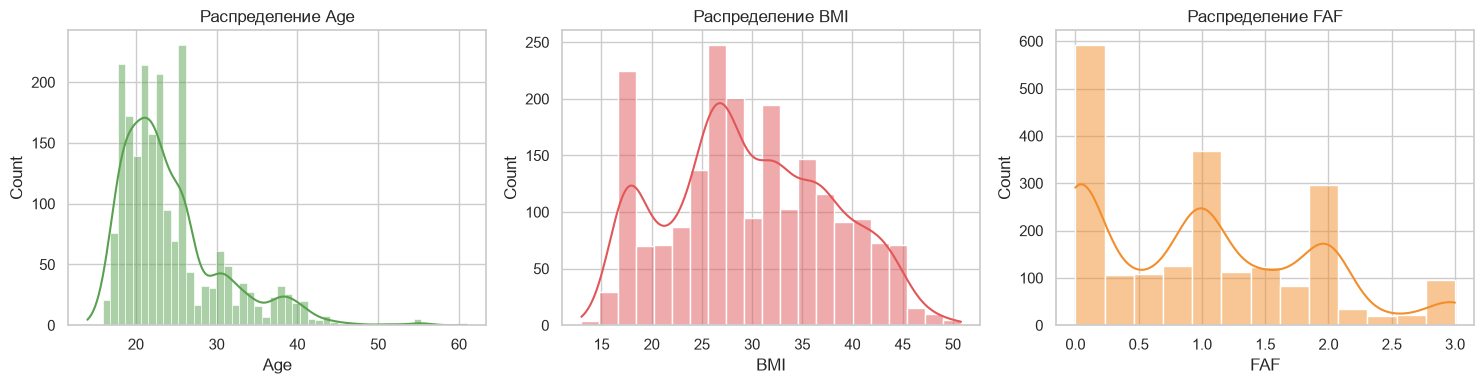

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(
    axes, ["Age", "BMI", "FAF"], ["#59A14F", "#E15759", "#F28E2B"]
):
    sns.histplot(df[col], kde=True, ax=ax, color=color)
    ax.set_title(f"Распределение {col}")
plt.tight_layout()
plt.show()

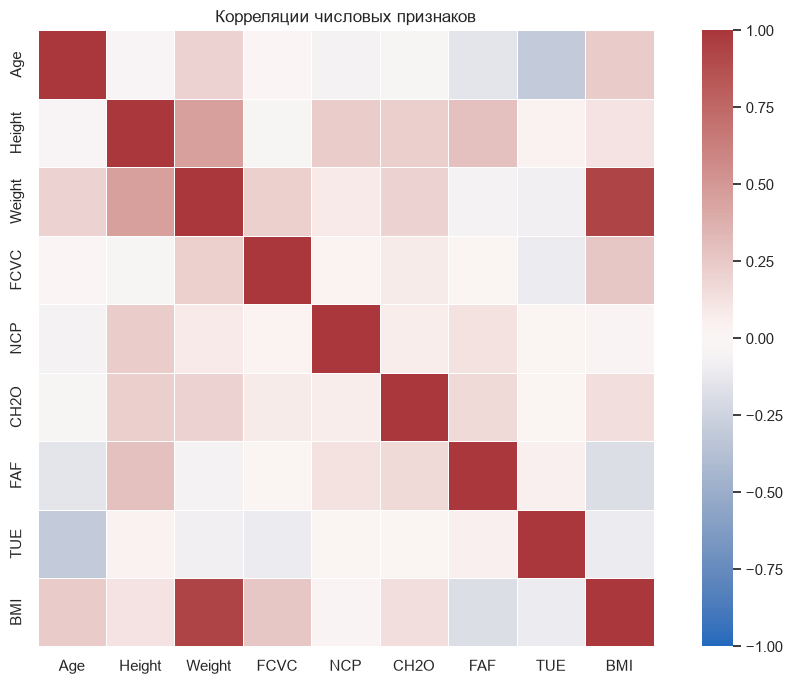

In [7]:
numeric_for_corr = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_for_corr.corr(),
    cmap="vlag", center=0, vmin=-1, vmax=1,
    square=True, linewidths=.4
)
plt.title("Корреляции числовых признаков")
plt.tight_layout()
plt.show()

Классы достаточно сбалансированы: отношение крупнейшего класса к наименьшему невелико. При этом `Weight`, `Height` и сконструированный из них `BMI` ожидаемо связаны между собой. Чтобы не переоценивать качество, далее используется стратифицированный отложенный тест, а подбор моделей проводится только на train-части.

## 3. Подготовка данных

In [8]:
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Train: (1669, 17) | Test: (418, 17)
Числовые признаки: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
Категориальные признаки: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


Все операции, которые «учатся» на данных (imputation, scaling, one-hot encoding и feature selection), находятся внутри `Pipeline`. В каждом фолде кросс-валидации они обучаются только на тренировочной части фолда.

## 4. Базовые модели и 5-fold кросс-валидация

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1
    )
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

cv_rows = []
baseline_fitted = {}
for name, model in models.items():
    pipe = Pipeline([("prep", clone(preprocessor)), ("model", model)])
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring,
        return_train_score=True, n_jobs=-1
    )
    pipe.fit(X_train, y_train)
    baseline_fitted[name] = pipe
    cv_rows.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_f1_macro_std": scores["test_f1_macro"].std(),
        "cv_train_f1_macro": scores["train_f1_macro"].mean()
    })

cv_results = pd.DataFrame(cv_rows).set_index("model").sort_values(
    "cv_f1_macro_mean", ascending=False
)
display(cv_results.style.format("{:.4f}"))

,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_train_f1_macro
model,,,,,
Random Forest,0.9808,0.0049,0.9797,0.0053,1.0000
Decision Tree,0.9700,0.0043,0.9693,0.0046,1.0000
Logistic Regression,0.8999,0.0226,0.8957,0.0236,0.9232


## 5. Подбор гиперпараметров

In [10]:
search_spaces = {
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
        {"model__C": [0.05, 0.1, 0.3, 1.0, 3.0, 10.0]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "model__max_depth": [4, 6, 8, 12, None],
            "model__min_samples_leaf": [1, 3, 8, 15],
            "model__criterion": ["gini", "entropy"]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [10, 16, None],
            "model__min_samples_leaf": [1, 3],
            "model__max_features": ["sqrt", 0.7]
        }
    )
}

searches = {}
for name, (model, grid) in search_spaces.items():
    search = GridSearchCV(
        Pipeline([("prep", clone(preprocessor)), ("model", model)]),
        param_grid=grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"{name}: CV macro-F1={search.best_score_:.4f}; {search.best_params_}")

Logistic Regression: CV macro-F1=0.9468; {'model__C': 10.0}


Decision Tree: CV macro-F1=0.9709; {'model__criterion': 'entropy', 'model__max_depth': 4, 'model__min_samples_leaf': 1}


Random Forest: CV macro-F1=0.9810; {'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


## 6. Финальная оценка на отложенном тесте

In [11]:
test_rows = []
for name, search in searches.items():
    pred = search.predict(X_test)
    test_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro"),
        "recall_macro": recall_score(y_test, pred, average="macro"),
        "f1_macro": f1_score(y_test, pred, average="macro")
    })

test_results = pd.DataFrame(test_rows).set_index("model").sort_values(
    "f1_macro", ascending=False
)
display(test_results.style.format("{:.4f}"))

best_name = test_results.index[0]
best_model = searches[best_name].best_estimator_
best_pred = best_model.predict(X_test)
print("Лучшая модель на test:", best_name)
print(classification_report(y_test, best_pred, digits=3))

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
Random Forest,0.9785,0.9784,0.9780,0.9778
Decision Tree,0.9713,0.9718,0.9702,0.9705
Logistic Regression,0.9498,0.9488,0.9494,0.9487


Лучшая модель на test: Random Forest
                     precision    recall  f1-score   support

Insufficient_Weight      1.000     1.000     1.000        53
      Normal_Weight      0.919     1.000     0.958        57
     Obesity_Type_I      1.000     0.986     0.993        70
    Obesity_Type_II      0.984     1.000     0.992        60
   Obesity_Type_III      1.000     0.985     0.992        65
 Overweight_Level_I      0.981     0.927     0.953        55
Overweight_Level_II      0.965     0.948     0.957        58

           accuracy                          0.978       418
          macro avg      0.978     0.978     0.978       418
       weighted avg      0.979     0.978     0.978       418



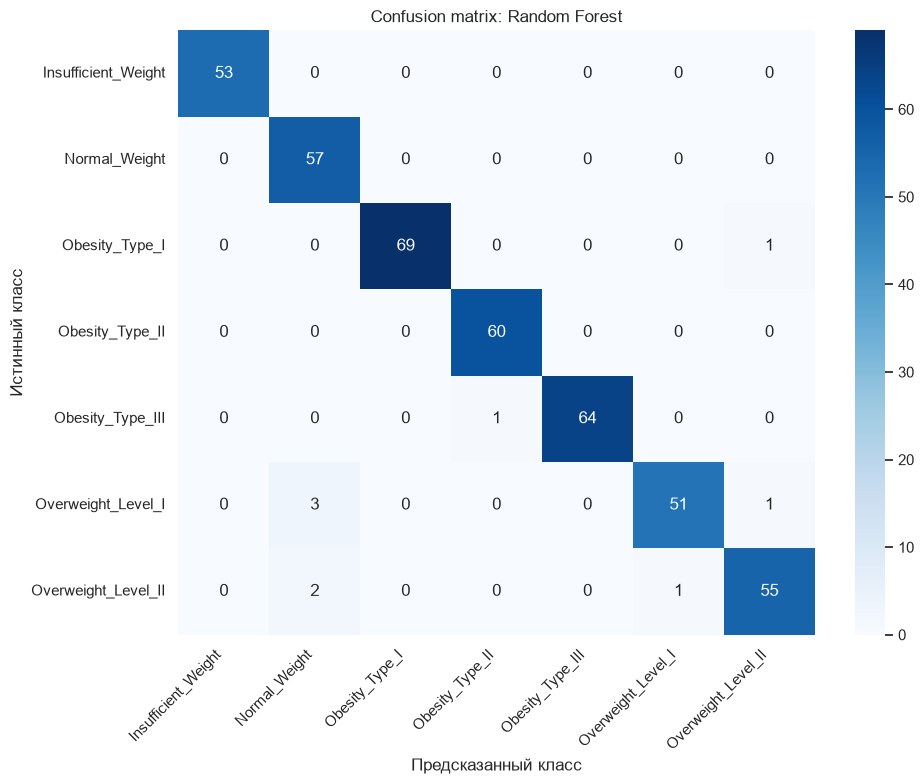

In [12]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels
)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title(f"Confusion matrix: {best_name}")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Проверка гипотез

### H1. Важность антропометрических признаков

In [13]:
rf_pipe = searches["Random Forest"].best_estimator_
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_
feature_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)

def original_feature(transformed_name):
    clean = transformed_name.split("__", 1)[1]
    if transformed_name.startswith("num__"):
        return clean
    for col in categorical_features:
        if clean == col or clean.startswith(col + "_"):
            return col
    return clean

aggregated_importance = (
    feature_importance.groupby([original_feature(x) for x in feature_importance.index])
    .sum().sort_values(ascending=False)
)
display(aggregated_importance.head(12).to_frame("importance"))

top3 = aggregated_importance.head(3).index.tolist()
h1_count = len(set(top3) & {"BMI", "Weight", "Height"})
h1 = h1_count >= 2
print("Топ-3 исходных признака:", top3)
display(Markdown(
    f"**H1 {'подтвердилась' if h1 else 'не подтвердилась'}:** "
    f"в топ-3 вошло {h1_count} из трёх антропометрических признаков."
))

,importance
BMI,0.310360
Weight,0.203088
Gender,0.061918
FCVC,0.056991
Age,0.054116
Height,0.050808
family_history_with_overweight,0.035216
NCP,0.034107
CALC,0.033587
CAEC,0.031824


Топ-3 исходных признака: ['BMI', 'Weight', 'Gender']


**H1 подтвердилась:** в топ-3 вошло 2 из трёх антропометрических признаков.

### H2–H3. Сравнение моделей и метрик

In [14]:
logreg_f1 = test_results.loc["Logistic Regression", "f1_macro"]
tree_f1 = test_results.loc["Decision Tree", "f1_macro"]
h2 = logreg_f1 > tree_f1

best_acc = test_results.loc[best_name, "accuracy"]
best_f1 = test_results.loc[best_name, "f1_macro"]
metric_gap = abs(best_acc - best_f1)
h3 = metric_gap < 0.02

display(Markdown(
    f"**H2 {'подтвердилась' if h2 else 'не подтвердилась'}:** "
    f"LogReg macro-F1={logreg_f1:.4f}, Decision Tree macro-F1={tree_f1:.4f}."
))
display(Markdown(
    f"**H3 {'подтвердилась' if h3 else 'не подтвердилась'}:** "
    f"у лучшей модели |accuracy − macro-F1|={metric_gap:.4f}."
))

**H2 не подтвердилась:** LogReg macro-F1=0.9487, Decision Tree macro-F1=0.9705.

**H3 подтвердилась:** у лучшей модели |accuracy − macro-F1|=0.0007.

### H4. Переобучение глубокого дерева

In [15]:
tree_depth_results = []
for depth in [5, None]:
    pipe = Pipeline([
        ("prep", clone(preprocessor)),
        ("model", DecisionTreeClassifier(
            max_depth=depth, random_state=RANDOM_STATE
        ))
    ])
    pipe.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    tree_depth_results.append({
        "max_depth": "None" if depth is None else str(depth),
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "gap": train_acc - test_acc
    })

tree_depth_results = pd.DataFrame(tree_depth_results).set_index("max_depth")
display(tree_depth_results.style.format("{:.4f}"))
h4 = tree_depth_results.loc["None", "gap"] > tree_depth_results.loc["5", "gap"]
display(Markdown(
    f"**H4 {'подтвердилась' if h4 else 'не подтвердилась'}:** "
    f"разрыв неограниченного дерева {tree_depth_results.loc['None', 'gap']:.4f}, "
    f"дерева глубины 5 — {tree_depth_results.loc['5', 'gap']:.4f}."
))

,train_accuracy,test_accuracy,gap
max_depth,,,
5,0.9868,0.9737,0.0131
None,1.0000,0.9689,0.0311


**H4 подтвердилась:** разрыв неограниченного дерева 0.0311, дерева глубины 5 — 0.0131.

### H5. Отбор признаков SelectKBest

In [16]:
best_logreg_c = searches["Logistic Regression"].best_params_["model__C"]
selected_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("select", SelectKBest(score_func=f_classif, k=10)),
    ("model", LogisticRegression(
        C=best_logreg_c, max_iter=3000, random_state=RANDOM_STATE
    ))
])
selected_cv = cross_validate(
    selected_pipe, X_train, y_train, cv=cv,
    scoring={"f1_macro": "f1_macro"}, n_jobs=-1
)
selected_pipe.fit(X_train, y_train)
selected_pred = selected_pipe.predict(X_test)
selected_test_f1 = f1_score(y_test, selected_pred, average="macro")
selection_drop = logreg_f1 - selected_test_f1

all_names = selected_pipe.named_steps["prep"].get_feature_names_out()
selected_names = all_names[selected_pipe.named_steps["select"].get_support()]
print("Выбранные преобразованные признаки:")
print(*selected_names, sep="\n")
print(f"CV macro-F1 после отбора: {selected_cv['test_f1_macro'].mean():.4f}")

h5 = selection_drop <= 0.02
display(Markdown(
    f"**H5 {'подтвердилась' if h5 else 'не подтвердилась'}:** "
    f"test macro-F1 с 10 признаками={selected_test_f1:.4f}; "
    f"изменение относительно полной LogReg={-selection_drop:+.4f}."
))

Выбранные преобразованные признаки:
num__Age
num__Weight
num__FCVC
num__BMI
cat__Gender_Female
cat__Gender_Male
cat__family_history_with_overweight_no
cat__family_history_with_overweight_yes
cat__CAEC_Frequently
cat__CAEC_Sometimes
CV macro-F1 после отбора: 0.9425


**H5 подтвердилась:** test macro-F1 с 10 признаками=0.9431; изменение относительно полной LogReg=-0.0056.

### H6. Семейная история и доля классов ожирения

In [17]:
obesity_flag = df[target].str.startswith("Obesity")
family_table = pd.crosstab(
    df["family_history_with_overweight"], obesity_flag
)
family_rates = pd.crosstab(
    df["family_history_with_overweight"], obesity_flag, normalize="index"
).rename(columns={False: "not_obesity", True: "obesity"})
chi2, family_p, _, _ = chi2_contingency(family_table)
family_diff = family_rates.loc["yes", "obesity"] - family_rates.loc["no", "obesity"]
display(family_rates.style.format("{:.3f}"))

h6 = (family_diff >= 0.10) and (family_p < 0.05)
display(Markdown(
    f"**H6 {'подтвердилась' if h6 else 'не подтвердилась'}:** "
    f"разница долей={family_diff:.3f}, χ² p-value={family_p:.2e}. "
    "Это ассоциация, а не доказательство причинности."
))

NObeyesdad,not_obesity,obesity
family_history_with_overweight,,
no,0.978,0.022
yes,0.440,0.560


**H6 подтвердилась:** разница долей=0.538, χ² p-value=1.14e-77. Это ассоциация, а не доказательство причинности.

### H7. Физическая активность и порядковый уровень массы тела

In [18]:
class_order = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6
}
severity = df[target].map(class_order)
faf_rho, faf_p = spearmanr(df["FAF"], severity)
h7 = (faf_rho < -0.15) and (faf_p < 0.05)

display(Markdown(
    f"**H7 {'подтвердилась' if h7 else 'не подтвердилась'}:** "
    f"Spearman ρ={faf_rho:.3f}, p-value={faf_p:.2e}. "
    "Связь слабая, но статистически значимая; причинный вывод делать нельзя."
))

**H7 подтвердилась:** Spearman ρ=-0.187, p-value=7.85e-18. Связь слабая, но статистически значимая; причинный вывод делать нельзя.

## 8. Итоговая таблица гипотез

In [19]:
hypothesis_summary = pd.DataFrame([
    ["H1", h1, f"{h1_count}/3 антропометрических признака в топ-3"],
    ["H2", h2, f"LogReg {logreg_f1:.4f} vs Tree {tree_f1:.4f}"],
    ["H3", h3, f"|accuracy − macro-F1| = {metric_gap:.4f}"],
    ["H4", h4, (
        f"gap None={tree_depth_results.loc['None','gap']:.4f}; "
        f"gap depth=5={tree_depth_results.loc['5','gap']:.4f}"
    )],
    ["H5", h5, f"изменение macro-F1 = {-selection_drop:+.4f}"],
    ["H6", h6, f"разница долей = {family_diff:.3f}; p={family_p:.2e}"],
    ["H7", h7, f"ρ={faf_rho:.3f}; p={faf_p:.2e}"],
], columns=["Гипотеза", "Подтвердилась", "Ключевой результат"])
display(hypothesis_summary)

,Гипотеза,Подтвердилась,Ключевой результат
0,H1,True,2/3 антропометрических признака в топ-3
1,H2,False,LogReg 0.9487 vs Tree 0.9705
2,H3,True,|accuracy − macro-F1| = 0.0007
3,H4,True,gap None=0.0311; gap depth=5=0.0131
4,H5,True,изменение macro-F1 = -0.0056
5,H6,True,разница долей = 0.538; p=1.14e-77
6,H7,True,ρ=-0.187; p=7.85e-18


## Ограничения

- Набор включает синтетические записи, поэтому высокая точность может не переноситься на реальные клинические данные.
- `BMI` вычислен из `Weight` и `Height`, а классы массы тела тесно связаны с этими показателями. Это полезно для сравнения моделей, но объясняет очень высокое качество.
- Статистические связи с семейной историей и физической активностью не доказывают причинность.
- Test-выборка использована только для финального сравнения уже настроенных моделей; гиперпараметры выбирались по CV на train-части.